In [1]:
import numpy as np
import pickle

filename = '20250702_014229'
with open(filename, 'rb') as file:
    data = pickle.load(file)

data.keys()

IsADirectoryError: [Errno 21] Is a directory: '20250702_014229'

In [2]:
import sys
import os

# Get the absolute path
folder_path = os.path.abspath("/home/vanregem/projects/lsip_Q_ONE/mc_trajectory_circuit_simulation/src/MPS_state_optimization")

# Add it to sys.path
if folder_path not in sys.path:
    sys.path.append(folder_path)

# Now import the module
from visualize_circuit import visualize_circuit

visualize_circuit(data["params"][-1], figsize=(4,6), fontsize=12, fontsize_cb=12)


NameError: name 'data' is not defined

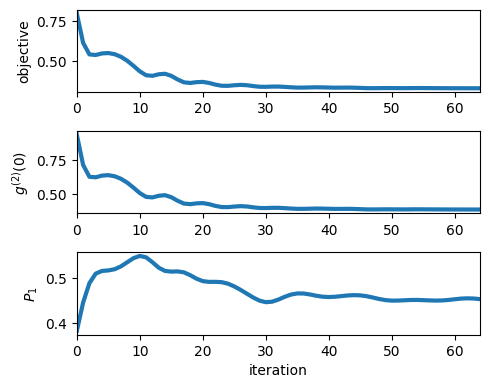

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,1, figsize=(5,4))
ax[0].plot(data['objective'], linewidth=3)
ax[0].set_ylabel("objective")
ax[1].plot(data['g2'], linewidth=3)
ax[1].set_ylabel(r"$g^{(2)}(0)$")
ax[2].plot(data['P1'], linewidth=3)
ax[2].set_ylabel(r"$P_1$")
ax[2].set_xlabel('iteration')

for a in ax:
    a.set_xlim([0,64])
plt.tight_layout()
plt.show()

In [3]:
import matplotlib.pyplot as plt

rho_ps = rho.copy()
rho_ps[:,0] = rho_ps[0,:] = 0
rho_ps = rho_ps / np.trace(rho_ps)

n = np.arange(rho_ps.shape[0])
Pn = np.diag(rho_ps)

g2 = np.sum(n*(n-1) * Pn) / np.sum(n*Pn)**2
print(f"g2: {g2.real}")

plt.matshow(rho_ps.real)

NameError: name 'rho' is not defined

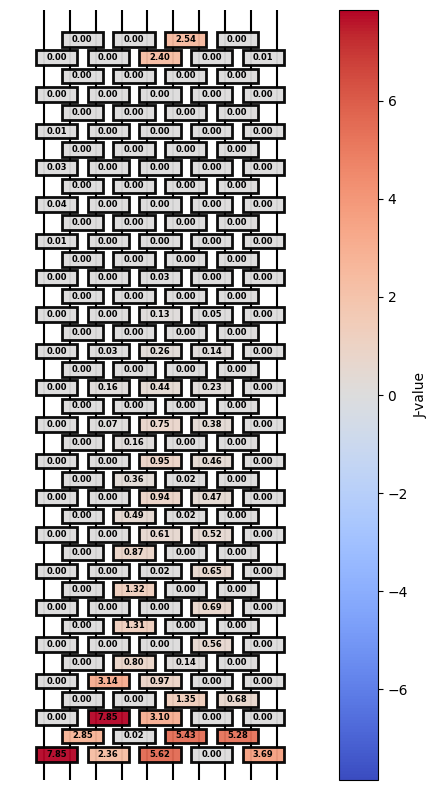

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def visualize_circuit(profile, dl=0.2, dg=0.5, frac_block=0.8, figsize=(5,10), save_path=None):

    num_layer = len(profile)
    num_wg = len(profile[0]) + 1
    width, height = 2 * dg * frac_block, dl * frac_block

    min_val = np.min([np.min([g for g in layer if g is not None]) for layer in profile])
    max_val = np.max([np.max([g for g in layer if g is not None]) for layer in profile])

    cmap = cm.coolwarm  # You can change this to another colormap like 'coolwarm', 'plasma', etc.
    lim_val = np.maximum(np.abs(min_val), np.abs(max_val))
    norm = mcolors.Normalize(vmin=-lim_val, vmax=lim_val)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(num_wg):
        ax.axvline(i * dg + width * frac_block / 4, color='k', zorder=0)

    for i_l, layer in enumerate(profile):
        for i_g, gate_val in enumerate(layer):
            
            if gate_val is None:
                continue

            y, x = dl * i_l, dg * i_g  # Bottom left
            color = cmap(norm(gate_val))  # Get color from colormap based on value
            rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor=color, alpha=0.95)
            ax.add_patch(rect)

            ax.text(x + width/2, y + height/2, f"{gate_val:.2f}", fontsize=6, ha='center', va='center', fontweight='bold', color='black')



    # Show the plot
    ax.set_xlim(-dg, (num_wg + 1) * dg)
    ax.set_ylim(-dl, (num_layer + 1) * dl)
    # ax.set_aspect('equal')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Add a colorbar
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label("J-value")

    if save_path is not None:
        plt.savefig(save_path)
    else:
        plt.show()



profile = data['params'][-1]
visualize_circuit(profile)

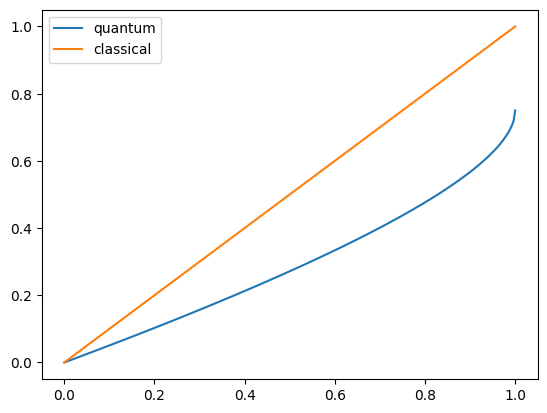

In [6]:
import matplotlib.pyplot as plt
import numpy as np

eta = np.linspace(0,1,300)
Pq = eta / 4 + 0.5 * (1 - np.sqrt(1 - eta))
Pc = eta

plt.plot(eta, Pq, label='quantum')
plt.plot(eta, Pc, label='classical')
plt.legend()

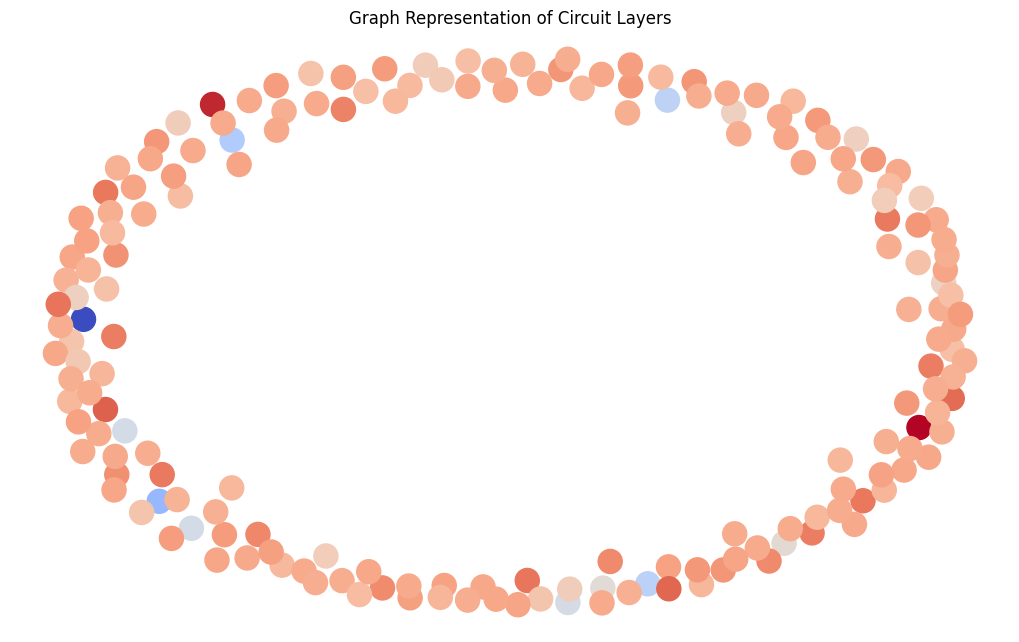

In [42]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_circuit_graph(data):
    """
    Plots a graph representation of circuit layers.
    :param data: 2D list where each value represents a connection strength, None means no connection.
    """
    G = nx.Graph()
    num_layers = len(data)
    num_modes = len(data[0])

    # Add nodes with values as attributes
    for l in range(num_layers):
        for i in range(num_modes):
            value = data[l][i]
            if value is not None:
                G.add_node((l, i), value=value)

    # Add edges between adjacent modes in the same layer
    for l in range(num_layers):
        for i in range(num_modes - 1):
            if data[l][i] is not None and data[l][i + 1] is not None:
                G.add_edge((l, i), (l, i + 1))

    # Get node values for coloring
    values = np.array([G.nodes[n]['value'] for n in G.nodes()])
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.cm.coolwarm

    # Draw graph
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42, k=0.5)  # Force-directed layout
    node_colors = [cmap(norm(G.nodes[n]['value'])) for n in G.nodes()]

    nx.draw(G, pos, with_labels=False, node_color=node_colors, edge_color="gray", node_size=300)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #plt.colorbar(sm, label="Coupling Strength")
    plt.title("Graph Representation of Circuit Layers")
    plt.show()

# Example usage:
data_example = data['params'][-1]

plot_circuit_graph(data_example)


In [39]:
data['params'][-1]

[[-1.801234483718872,
  None,
  2.0383877754211426,
  None,
  -4.062794208526611,
  None,
  2.1077964305877686,
  None,
  -5.262896537780762],
 [None,
  4.521998405456543,
  None,
  2.144352436065674,
  None,
  -7.202089309692383,
  None,
  -1.1360074281692505,
  None],
 [-1.8713306188583374,
  None,
  -5.43253231048584,
  None,
  -4.086512088775635,
  None,
  -1.6322813034057617,
  None,
  -11.958674430847168],
 [None,
  -3.9266855716705322,
  None,
  -3.0724363327026367,
  None,
  0.6705058217048645,
  None,
  -1.860934853553772,
  None],
 [-0.6774533987045288,
  None,
  0.8536565899848938,
  None,
  -1.3065990209579468,
  None,
  0.8956205248832703,
  None,
  -5.936412811279297],
 [None,
  -0.9080695509910583,
  None,
  -1.9204273223876953,
  None,
  0.06456612795591354,
  None,
  -2.047637701034546,
  None],
 [-0.3535766899585724,
  None,
  1.2213472127914429,
  None,
  -0.629466712474823,
  None,
  1.5020767450332642,
  None,
  5.073351860046387],
 [None,
  1.1272081136703491,
  N